# Forecasting Voltage Fluctuations in Smart Grids Using a CNN–Transformer Hybrid Model

This notebook presents the complete workflow for forecasting short-term voltage fluctuations in a multi-node smart grid using a CNN–Transformer hybrid architecture.

The workflow includes:

- Data loading and preprocessing
- Multi-node feature engineering
- Sequence generation
- CNN–Transformer model development
- Model training and evaluation
- Baseline model comparison
- Sensitivity analysis

> **Dataset Availability**
>
> The original SoCal28Bus digital twin dataset used in this research is not included in this repository because it was obtained under restricted academic access. The repository includes the notebook, supporting documentation, and generated evaluation outputs.

## Setup and Dependencies

This section imports the Python libraries required for data preprocessing, visualisation, machine learning, and deep learning.

In [ ]:
# ===========================
# Standard Library
# ===========================

from pathlib import Path
import os
import time

# ===========================
# Data Manipulation
# ===========================

import numpy as np
import pandas as pd

# ===========================
# Data Visualisation
# ===========================

import matplotlib.pyplot as plt
import seaborn as sns

# ===========================
# Machine Learning
# ===========================

from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

# ===========================
# Deep Learning
# ===========================

import tensorflow as tf

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Input,
    Conv1D,
    Dense,
    Dropout,
    LayerNormalization,
    GlobalAveragePooling1D,
    MultiHeadAttention,
    Add,
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
)

from tensorflow.keras.optimizers import Adam

## Data Loading and Initial Preprocessing

This section loads the Bus 1 and Bus 2 datasets, converts timestamp columns into datetime format, and performs initial validation before constructing the multi-node dataset.

The original SoCal28Bus dataset is not distributed with this repository. The code below demonstrates how the Bus 1 and Bus 2 datasets were loaded during model development. File paths may need to be updated to match the local environment.

In [ ]:
# ==========================
# Load datasets
# ==========================

BUS1_FILE = DATA_DIR / "bus_1_master.csv"
BUS2_FILE = DATA_DIR / "bus_2_master.csv"

bus1 = pd.read_csv(BUS1_FILE)
bus2 = pd.read_csv(BUS2_FILE)

# ==========================
# Display dataset dimensions
# ==========================

print(f"Bus 1: {bus1.shape}")
print(f"Bus 2: {bus2.shape}")

# ==========================
# Convert timestamps
# ==========================

bus1["t"] = pd.to_datetime(bus1["t"])
bus2["t"] = pd.to_datetime(bus2["t"])

### Data Validation

Before feature engineering, the datasets are inspected for missing values to ensure data quality and identify potential preprocessing requirements.

In [ ]:
# ==========================
# Missing value check
# ==========================

print("Missing Values Summary")
print("-" * 30)

print("\nBus 1")
print(bus1.isnull().sum())

print("\nBus 2")
print(bus2.isnull().sum())

## Prepare Multi-Node Features

This section prepares the input features required for multi-node voltage forecasting by combining measurements from Bus 1 and Bus 2 into a unified dataset.

The preprocessing includes:

- Selecting the relevant electrical measurements.
- Renaming features to distinguish between buses.
- Merging both datasets using their timestamps.
- Creating the target variable for voltage prediction.

The resulting dataset forms the basis for sequence generation and model training.

In [ ]:
# ==========================
# Select Relevant Features
# ==========================
voltage_cols_bus1 = [
    'egauge_1-L1', 'egauge_1-L2', 'egauge_1-L3',
    'L1_frequency', 'L1_rms', 'L1_phase',
    'L2_frequency', 'L2_rms', 'L2_phase',
    'L3_frequency', 'L3_rms', 'L3_phase'
]

voltage_cols_bus2 = [
    'egauge_2-L1', 'egauge_2-L2', 'egauge_2-L3',
    'L1_frequency', 'L1_rms', 'L1_phase',
    'L2_frequency', 'L2_rms', 'L2_phase',
    'L3_frequency', 'L3_rms', 'L3_phase'
]

df1 = bus1[voltage_cols_bus1].copy()
df2 = bus2[voltage_cols_bus2].copy()

# Rename columns with bus prefix
df1.columns = [f'bus1_{col}' for col in ['V_L1', 'V_L2', 'V_L3', 'freq_L1', 'rms_L1', 'phase_L1',
                                          'freq_L2', 'rms_L2', 'phase_L2', 'freq_L3', 'rms_L3', 'phase_L3']]
df2.columns = [f'bus2_{col}' for col in ['V_L1', 'V_L2', 'V_L3', 'freq_L1', 'rms_L1', 'phase_L1',
                                          'freq_L2', 'rms_L2', 'phase_L2', 'freq_L3', 'rms_L3', 'phase_L3']]

print("Bus 1 features:", df1.columns.tolist()[:6], "...")
print("Bus 2 features:", df2.columns.tolist()[:6], "...")

In [ ]:
# ==========================
# Combine Multi-Node Features
# ==========================

# Join both datasets using the timestamp index

df_multi = df1.join(df2, how='inner')

print(f"\nCombined multi-node dataset: {df_multi.shape}")
print(f"Features: {df_multi.shape[1]} (12 from Bus 1 + 12 from Bus 2)")
print(f"Samples: {df_multi.shape[0]}")

# ==========================
# Handle Missing Values
# ==========================

df_multi = df_multi.fillna(method='ffill').fillna(method='bfill').dropna()

print(f"After cleaning: {df_multi.shape}")
print(f"Remaining NaNs: {df_multi.isnull().sum().sum()}")


Combined multi-node dataset: (43992, 24)
Features: 24 (12 from Bus 1 + 12 from Bus 2)
Samples: 43992
After cleaning: (43992, 24)
Remaining NaNs: 0


### Dataset Summary

The combined multi-node dataset is summarised below to verify the distribution and range of the selected electrical measurements before visualisation and sequence generation.

In [7]:
df_multi.describe()

,bus1_V_L1,bus1_V_L2,bus1_V_L3,bus1_freq_L1,bus1_rms_L1,bus1_phase_L1,bus1_freq_L2,bus1_rms_L2,bus1_phase_L2,bus1_freq_L3,...,bus2_V_L3,bus2_freq_L1,bus2_rms_L1,bus2_phase_L1,bus2_freq_L2,bus2_rms_L2,bus2_phase_L2,bus2_freq_L3,bus2_rms_L3,bus2_phase_L3
count,43992.000000,43992.000000,43992.000000,43992.000000,43992.000000,43992.000000,43992.000000,43992.000000,43992.000000,43992.000000,...,43992.000000,43992.000000,43992.000000,43992.000000,43992.000000,43992.000000,43992.000000,43992.000000,43992.000000,43992.000000
mean,279.558075,279.654615,279.423155,59.999635,279.191449,-0.875010,59.999567,279.285521,1.065293,59.999615,...,279.782794,59.999743,280.713071,-1.024188,59.999747,279.327922,0.962168,59.999705,279.251480,0.473840
std,4.713707,4.699603,4.694798,0.019590,0.858131,103.985960,0.019643,0.848920,103.669885,0.019608,...,2.235553,0.019576,0.891447,103.840446,0.019606,0.859425,103.521324,0.019593,0.837355,104.286937
min,28.949985,30.436301,30.165718,59.912528,276.559963,-179.997615,59.890998,276.304186,-179.992522,59.912528,...,140.121491,59.912528,277.888636,-179.994586,59.912528,276.404558,-179.997678,59.912528,276.521009,-179.996046
25%,279.186450,279.273300,279.072000,59.991601,278.599806,-91.219718,59.991601,278.687860,-88.628657,59.991601,...,279.256600,59.991601,280.108600,-90.759183,59.991601,278.714321,-89.055952,59.991601,278.677945,-90.625047
50%,279.776800,279.867150,279.639400,59.995200,279.189316,-0.451016,59.995200,279.277154,0.495627,59.995200,...,279.834600,60.006001,280.709416,-1.065750,60.006001,279.354168,1.395447,60.006001,279.259913,1.276285
75%,280.345125,280.461000,280.209125,60.009602,279.751626,89.415971,60.009602,279.866950,90.851122,60.009602,...,280.385225,60.009602,281.272574,89.506408,60.009602,279.902557,90.337961,60.009602,279.812256,91.086781
max,283.451900,283.658800,283.103600,60.052847,282.915153,179.997092,60.052847,283.109727,179.997115,60.052847,...,283.301700,60.052847,284.542236,179.999319,60.052847,283.261830,179.993932,60.052847,282.799250,179.988647


## Visualise Multi-Node Data

This section explores the merged multi-node dataset to understand voltage behaviour and relationships between Bus 1 and Bus 2 before sequence generation.

The visualisations help verify data quality, identify temporal patterns, and assess the correlation between voltage measurements across both buses.

### Voltage Profile Comparison

The voltage profiles of Bus 1 and Bus 2 are visualised to examine temporal behaviour and identify similarities or differences in voltage fluctuations across both nodes.

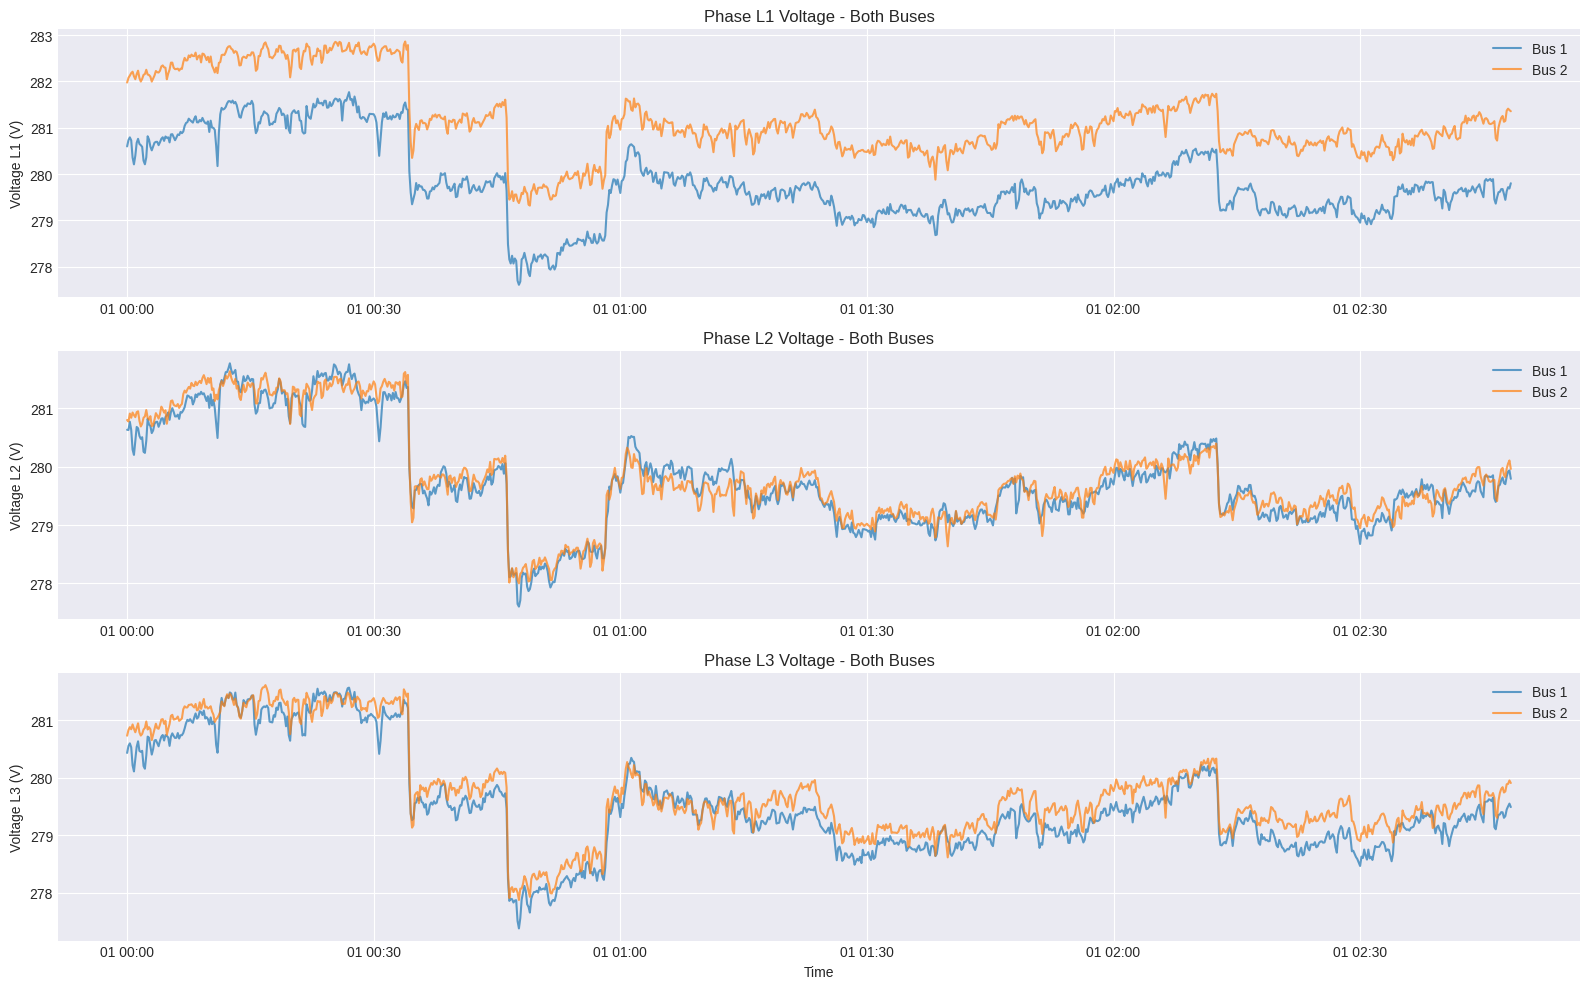

In [ ]:
# Voltage Profile Comparison

fig, axes = plt.subplots(3, 1, figsize=(16, 10))
sample = df_multi.iloc[:1000]

axes[0].plot(sample.index, sample['bus1_V_L1'], label='Bus 1', alpha=0.7)
axes[0].plot(sample.index, sample['bus2_V_L1'], label='Bus 2', alpha=0.7)
axes[0].set_ylabel('Voltage L1 (V)')
axes[0].set_title('Phase L1 Voltage - Both Buses')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(sample.index, sample['bus1_V_L2'], label='Bus 1', alpha=0.7)
axes[1].plot(sample.index, sample['bus2_V_L2'], label='Bus 2', alpha=0.7)
axes[1].set_ylabel('Voltage L2 (V)')
axes[1].set_title('Phase L2 Voltage - Both Buses')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(sample.index, sample['bus1_V_L3'], label='Bus 1', alpha=0.7)
axes[2].plot(sample.index, sample['bus2_V_L3'], label='Bus 2', alpha=0.7)
axes[2].set_ylabel('Voltage L3 (V)')
axes[2].set_xlabel('Time')
axes[2].set_title('Phase L3 Voltage - Both Buses')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

### Correlation Analysis

A correlation analysis is performed to quantify the relationships between electrical measurements from both buses. Strong correlations indicate shared operating behaviour, while weaker correlations may reveal localised variations within the smart grid.

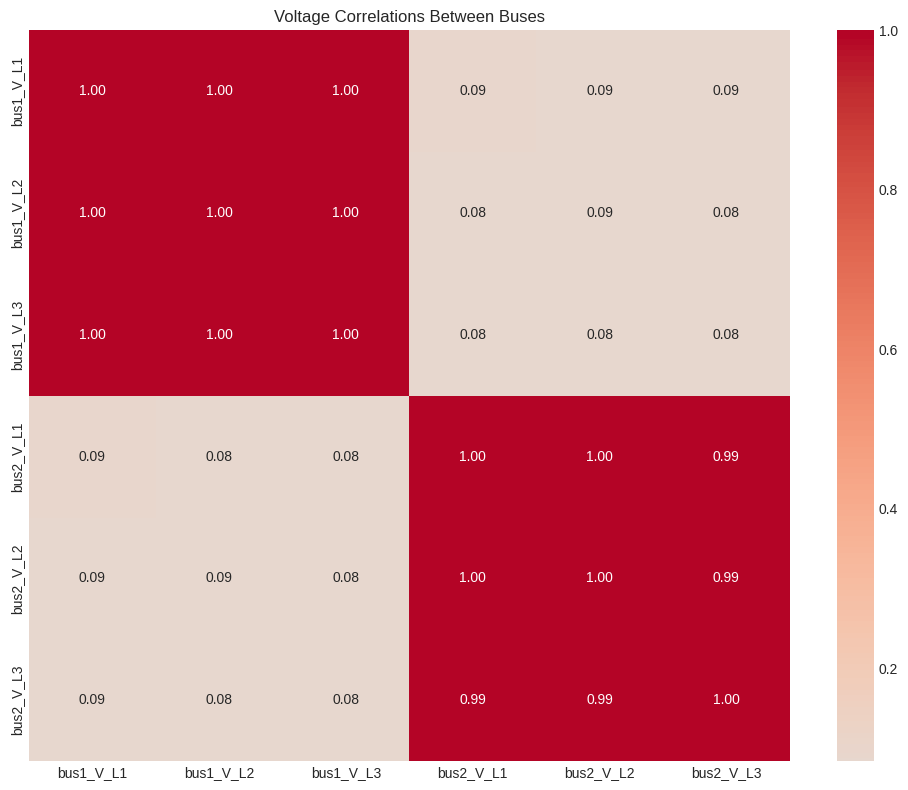

In [ ]:
# Correlation Analysis

voltage_only = df_multi[[col for col in df_multi.columns if 'V_L' in col]]

plt.figure(figsize=(10, 8))
sns.heatmap(voltage_only.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Voltage Correlations Between Buses')
plt.tight_layout()
plt.show()

### Visualisation Summary

The exploratory analysis confirms that the merged dataset preserves meaningful temporal and spatial relationships between Bus 1 and Bus 2. These observations provide confidence that the engineered features are suitable for sequence generation and deep learning.

## Prepare Multi-Node Sequences

This section transforms the engineered multi-node dataset into supervised learning sequences suitable for deep learning.

A sliding window approach is used to generate input-output pairs, where each input sequence contains historical observations and each target sequence contains the future voltage values to be predicted. The resulting datasets are then divided into training, validation, and testing sets.

In [ ]:
# Convert DataFrame to NumPy Array

data = df_multi.values
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

print(f"Multi-node data shape: {data_scaled.shape}")
print(f"Features per timestep: {data_scaled.shape[1]}")
print(f"Scaled range: [{data_scaled.min():.2f}, {data_scaled.max():.2f}]")

Multi-node data shape: (43992, 24)
Features per timestep: 24
Scaled range: [0.00, 1.00]


### Sliding Window Sequence Generation

A custom sequence generation function is used to convert the continuous multivariate time-series into supervised learning samples.

Each input sequence contains a fixed number of historical observations (`lookback`), while the corresponding target sequence contains the future voltage values over the prediction horizon.

In [11]:
def create_sequences(data, lookback, horizon):
    X, y = [], []
    for i in range(len(data) - lookback - horizon + 1):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback:i+lookback+horizon])
    return np.array(X), np.array(y)

LOOKBACK = 60  # 10 minutes of history
HORIZON = 6    # 1 minute ahead prediction

X, y = create_sequences(data_scaled, LOOKBACK, HORIZON)

print(f"\nSequence shapes:")
print(f"X: {X.shape} (samples, lookback, features)")
print(f"y: {y.shape} (samples, horizon, features)")
print(f"\nEach sample contains:")
print(f"  - {LOOKBACK} past timesteps")
print(f"  - {X.shape[2]} features (12 from each bus)")
print(f"  - Predicts {HORIZON} future timesteps")


Sequence shapes:
X: (43927, 60, 24) (samples, lookback, features)
y: (43927, 6, 24) (samples, horizon, features)

Each sample contains:
  - 60 past timesteps
  - 24 features (12 from each bus)
  - Predicts 6 future timesteps


### Dataset Partitioning

The generated sequences are divided into training, validation, and testing datasets using a chronological split.

Maintaining the temporal order prevents information leakage and ensures that model performance is evaluated on unseen future observations.

In [ ]:
# Training, Validation and Test Split

# Split: 70% train, 15% val, 15% test

n = len(X)
train_end = int(n * 0.70)
val_end = train_end + int(n * 0.15)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

print(f"Train: {len(X_train):,} samples ({len(X_train)/n*100:.1f}%)")
print(f"Val:   {len(X_val):,} samples ({len(X_val)/n*100:.1f}%)")
print(f"Test:  {len(X_test):,} samples ({len(X_test)/n*100:.1f}%)")

Train: 30,748 samples (70.0%)
Val:   6,589 samples (15.0%)
Test:  6,590 samples (15.0%)


### Sequence Preparation Summary

The resulting datasets are now organised into training, validation, and testing sets, providing the input required for CNN feature extraction and Transformer-based temporal learning.

## Build Multi-Node CNN–Transformer Model

This section defines the deep learning architecture used for multi-node voltage forecasting.

The proposed model combines:

- **1D Convolutional Neural Networks (CNNs)** to extract local temporal patterns.
- **Transformer Encoder blocks** to capture long-range temporal dependencies through self-attention.
- **Dense output layers** to generate multi-step voltage forecasts across multiple buses.

This hybrid architecture leverages the strengths of convolutional feature extraction and Transformer-based sequence modelling to improve forecasting performance.

### Transformer Encoder

The custom Transformer encoder block enables the model to learn long-range temporal dependencies using multi-head self-attention and residual learning.

This component complements the convolutional layers by modelling relationships that extend beyond local receptive fields.

In [ ]:
# Transformer Encoder Block

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)

    def call(self, x, training=False):
        attn = self.att(x, x)
        attn = self.dropout1(attn, training=training)
        x = self.norm1(x + attn)

        ffn = self.ffn(x)
        ffn = self.dropout2(ffn, training=training)
        return self.norm2(x + ffn)

### CNN–Transformer Architecture

The CNN–Transformer model integrates convolutional layers for local feature extraction with Transformer encoder layers for global temporal modelling.

The resulting architecture learns both short-term voltage fluctuations and long-term temporal dependencies before generating multi-step voltage predictions.

In [ ]:
def build_multinode_model(input_shape, horizon, n_features):
    """
    Multi-node CNN-Transformer model.

    The CNN layers extract spatial features across the two buses,
    while Transformer blocks capture temporal dependencies.
    """
    inputs = Input(shape=input_shape)

    # CNN layers - extract spatial patterns across buses
    x = layers.Conv1D(64, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.1)(x)

    x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.1)(x)

    # Transformer blocks - capture temporal dependencies
    x = TransformerBlock(128, 4, 128, 0.1)(x)
    x = TransformerBlock(128, 4, 128, 0.1)(x)

    x = layers.GlobalAveragePooling1D()(x)

    # Dense layers
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.1)(x)

    # Output for both buses
    outputs = layers.Dense(horizon * n_features)(x)
    outputs = layers.Reshape((horizon, n_features))(outputs)

    return Model(inputs, outputs, name='MultiNode_CNN_Transformer')

model = build_multinode_model(
    input_shape=(LOOKBACK, X_train.shape[2]),
    horizon=HORIZON,
    n_features=X_train.shape[2]
)

model.summary()

## Model Summary

The model summary below provides the network architecture together with the number of trainable and non-trainable parameters.

This information gives an overview of the model complexity before training begins.

In [ ]:
# Model Summary

trainable = sum([np.prod(v.shape) for v in model.trainable_weights])
non_trainable = sum([np.prod(v.shape) for v in model.non_trainable_weights])

print(f"\nModel parameters:")
print(f"  Trainable: {trainable:,}")
print(f"  Non-trainable: {non_trainable:,}")
print(f"  Total: {trainable + non_trainable:,}")


Model parameters:
  Trainable: 708,944
  Non-trainable: 384
  Total: 709,328


## 7. Compile and Train Model

This section compiles the CNN–Transformer model, configures the optimisation strategy, and trains the network using the prepared multi-node sequences.

Training incorporates early stopping and adaptive learning rate scheduling to improve convergence, reduce overfitting, and preserve the best-performing model.

In [ ]:
# Compile Model

model.compile(
    optimizer=Adam(0.001),
    loss='mse',
    metrics=['mae', 'mape']
)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6
    ),
    ModelCheckpoint(
        '/home/claude/best_multinode_model.keras',
        monitor='val_loss',
        save_best_only=True
    )
]

print("Model compiled successfully")

Model compiled successfully


### Model Training

The CNN–Transformer model is trained using the training dataset while performance is monitored on the validation dataset.

Early stopping restores the best-performing model, whereas learning rate reduction improves optimisation when validation performance plateaus.

In [ ]:
# Training Configuration

BATCH_SIZE = 32
EPOCHS = 100

print(f"Training multi-node model with batch size {BATCH_SIZE}, max {EPOCHS} epochs")
print(f"Train: {len(X_train):,}, Val: {len(X_val):,}\n")

start = time.time()

# Train CNN–Transformer Model

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start
print(f"\nTraining completed in {training_time/60:.2f} minutes")

### Training Performance

The learning curves below illustrate the optimisation process by comparing training and validation performance throughout model training.

These plots help assess convergence behaviour and identify potential overfitting or underfitting.

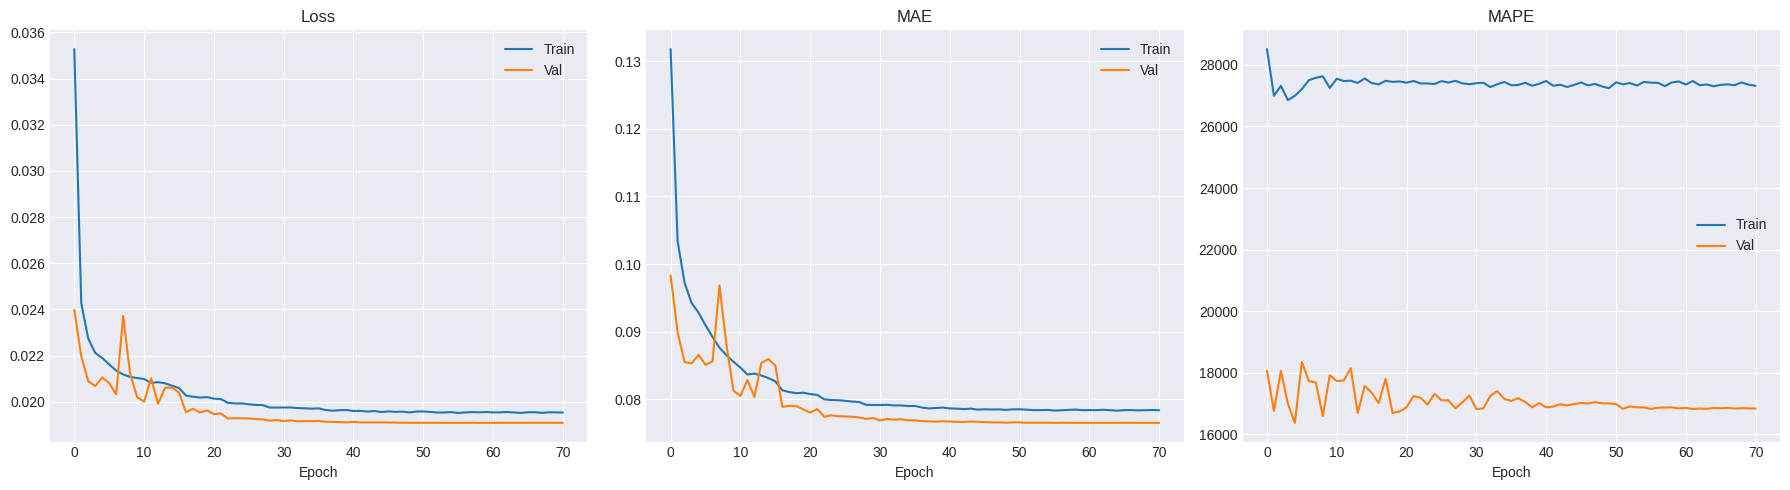

In [ ]:
# Plot Training History

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['mae'], label='Train')
axes[1].plot(history.history['val_mae'], label='Val')
axes[1].set_title('MAE')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(history.history['mape'], label='Train')
axes[2].plot(history.history['val_mape'], label='Val')
axes[2].set_title('MAPE')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

### Training Summary

The training process demonstrates the convergence behaviour of the proposed CNN–Transformer model. The resulting trained network is subsequently evaluated on the unseen test dataset and compared with baseline forecasting approaches.

## 8. Evaluate on the Test Set

This section evaluates the trained CNN–Transformer model on the unseen test dataset.

Model predictions are generated and compared with the ground truth voltage measurements to assess the forecasting performance before benchmarking against baseline approaches.

In [ ]:
# Generate Test Predictions

start = time.time()
y_pred = model.predict(X_test, batch_size=BATCH_SIZE)
inference_time = time.time() - start

print(f"Inference: {inference_time:.2f}s")
print(f"Per sample: {inference_time/len(X_test)*1000:.2f}ms")

206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Inference: 1.11s
Per sample: 0.17ms


### Test Set Evaluation Summary

The CNN–Transformer model has been evaluated using unseen test data, providing an objective assessment of its forecasting capability. The following section compares these results with baseline forecasting methods to determine the effectiveness of the proposed architecture.

In [ ]:
# Per-Bus and Per-Phase Evaluation

def metrics_1d(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true.flatten(), y_pred.flatten()))
    mae  = mean_absolute_error(y_true.flatten(), y_pred.flatten())
    r2   = r2_score(y_true.flatten(), y_pred.flatten())
    return rmse, mae, r2

target_map = [
    ("Bus 1","L1",0), ("Bus 1","L2",1), ("Bus 1","L3",2),
    ("Bus 2","L1",12), ("Bus 2","L2",13), ("Bus 2","L3",14),
]

rows=[]
for bus, ph, idx in target_map:
    rmse, mae, r2 = metrics_1d(y_test_volts[:,:,idx], y_pred_volts[:,:,idx])
    rows.append({"Model":"Multi-Node CNN-Transformer","Bus":bus,"Phase":ph,"RMSE":rmse,"MAE":mae,"R2":r2})

df = pd.DataFrame(rows)
df.to_csv("/content/cnn_transformer_voltage_per_bus_phase_metrics_volts.csv", index=False)
print(df)
print("Saved: /content/cnn_transformer_voltage_per_bus_phase_metrics_volts.csv")


                        Model    Bus Phase      RMSE       MAE        R2
0  Multi-Node CNN-Transformer  Bus 1    L1  3.810025  0.691697  0.045460
1  Multi-Node CNN-Transformer  Bus 1    L2  3.826406  0.744531  0.031722
2  Multi-Node CNN-Transformer  Bus 1    L3  3.811285  0.695195  0.039306
3  Multi-Node CNN-Transformer  Bus 2    L1  3.128629  0.368892  0.080818
4  Multi-Node CNN-Transformer  Bus 2    L2  3.105480  0.314999  0.069263
5  Multi-Node CNN-Transformer  Bus 2    L3  3.105877  0.328659  0.073892
Saved: /content/cnn_transformer_voltage_per_bus_phase_metrics_volts.csv


### Multi-Level Forecast Evaluation

The CNN–Transformer predictions are evaluated using multiple performance metrics at different levels of analysis, including overall forecasting performance, per-bus evaluation, per-phase evaluation, and voltage-only forecasting accuracy.

In [ ]:
# Voltage-Only Evaluation

# Voltage RMS channels only (Bus1 L1–L3, Bus2 L1–L3)
target_idx = [0, 1, 2, 12, 13, 14]

yt = y_test_volts[:, :, target_idx].flatten()
yp = y_pred_volts[:, :, target_idx].flatten()

rmse_v = np.sqrt(mean_squared_error(yt, yp))
mae_v  = mean_absolute_error(yt, yp)
r2_v   = r2_score(yt, yp)

print("\nVoltage-only VOLTS Results (6 RMS channels):")
print("RMSE (V):", rmse_v)
print("MAE  (V):", mae_v)
print("R2:", r2_v)

results_volts_voltage = {
    "Model": "Multi-Node CNN-Transformer",
    "Nodes": "Bus 1 + Bus 2",
    "Targets": "Bus1 RMS L1–L3 + Bus2 RMS L1–L3",
    "Overall RMSE (V)": float(rmse_v),
    "Overall MAE (V)": float(mae_v),
    "Overall R2": float(r2_v),
}

pd.DataFrame([results_volts_voltage]).to_csv("/content/multinode_results_volts_voltage_only.csv", index=False)
print("Saved: /content/multinode_results_volts_voltage_only.csv")



Voltage-only VOLTS Results (6 RMS channels):
RMSE (V): 3.4823927615509156
MAE  (V): 0.523995421835708
R2: 0.07734355636986401
Saved: /content/multinode_results_volts_voltage_only.csv


## Compare with Baseline Models

This section evaluates the forecasting performance of the proposed CNN–Transformer model and compares it with baseline approaches using standard regression metrics.

Performance is assessed at multiple levels, including overall forecasting accuracy, per-bus performance, and voltage prediction quality.

In [ ]:
# Overall Performance Metrics

y_true_flat = y_test.reshape(-1)
y_pred_flat = y_pred.reshape(-1)

rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
mae = mean_absolute_error(y_true_flat, y_pred_flat)
mape = np.mean(np.abs((y_true_flat - y_pred_flat) / (y_true_flat + 1e-10))) * 100
r2 = r2_score(y_true_flat, y_pred_flat)

print("\nOverall Test Results (Both Buses):")
print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²:   {r2:.6f}")


Overall Test Results (Both Buses):
RMSE: 0.139010
MAE:  0.077365
MAPE: 27785920.97%
R²:   0.761990


### Per-Bus Evaluation

Performance is evaluated separately for each bus to determine how effectively the CNN–Transformer model captures voltage behaviour across different nodes within the smart grid.

In [ ]:
# Per-Bus Voltage Performance

bus1_voltage_indices = [0, 1, 2]  # bus1_V_L1, bus1_V_L2, bus1_V_L3
bus2_voltage_indices = [12, 13, 14]  # bus2_V_L1, bus2_V_L2, bus2_V_L3

print("\n" + "="*60)
print("BUS 1 VOLTAGE METRICS")
print("="*60)

bus1_metrics = {}
for i, phase in enumerate(['L1', 'L2', 'L3']):
    idx = bus1_voltage_indices[i]
    y_t = y_test[:, :, idx].flatten()
    y_p = y_pred[:, :, idx].flatten()

    rmse_v = np.sqrt(mean_squared_error(y_t, y_p))
    mae_v = mean_absolute_error(y_t, y_p)
    r2_v = r2_score(y_t, y_p)

    bus1_metrics[phase] = {'RMSE': rmse_v, 'MAE': mae_v, 'R2': r2_v}

    print(f"\nPhase {phase}:")
    print(f"  RMSE: {rmse_v:.6f}")
    print(f"  MAE:  {mae_v:.6f}")
    print(f"  R²:   {r2_v:.6f}")

print("\n" + "="*60)
print("BUS 2 VOLTAGE METRICS")
print("="*60)

bus2_metrics = {}
for i, phase in enumerate(['L1', 'L2', 'L3']):
    idx = bus2_voltage_indices[i]
    y_t = y_test[:, :, idx].flatten()
    y_p = y_pred[:, :, idx].flatten()

    rmse_v = np.sqrt(mean_squared_error(y_t, y_p))
    mae_v = mean_absolute_error(y_t, y_p)
    r2_v = r2_score(y_t, y_p)

    bus2_metrics[phase] = {'RMSE': rmse_v, 'MAE': mae_v, 'R2': r2_v}

    print(f"\nPhase {phase}:")
    print(f"  RMSE: {rmse_v:.6f}")
    print(f"  MAE:  {mae_v:.6f}")
    print(f"  R²:   {r2_v:.6f}")


BUS 1 VOLTAGE METRICS

Phase L1:
  RMSE: 0.014971
  MAE:  0.002718
  R²:   0.045460

Phase L2:
  RMSE: 0.015111
  MAE:  0.002940
  R²:   0.031721

Phase L3:
  RMSE: 0.015068
  MAE:  0.002748
  R²:   0.039306

BUS 2 VOLTAGE METRICS

Phase L1:
  RMSE: 0.021691
  MAE:  0.002558
  R²:   0.080819

Phase L2:
  RMSE: 0.021633
  MAE:  0.002194
  R²:   0.069262

Phase L3:
  RMSE: 0.021692
  MAE:  0.002295
  R²:   0.073892


### Prediction Visualisation

The predicted voltage values are compared with the corresponding ground truth measurements to visually assess forecasting accuracy and identify agreement between predicted and observed voltage profiles.

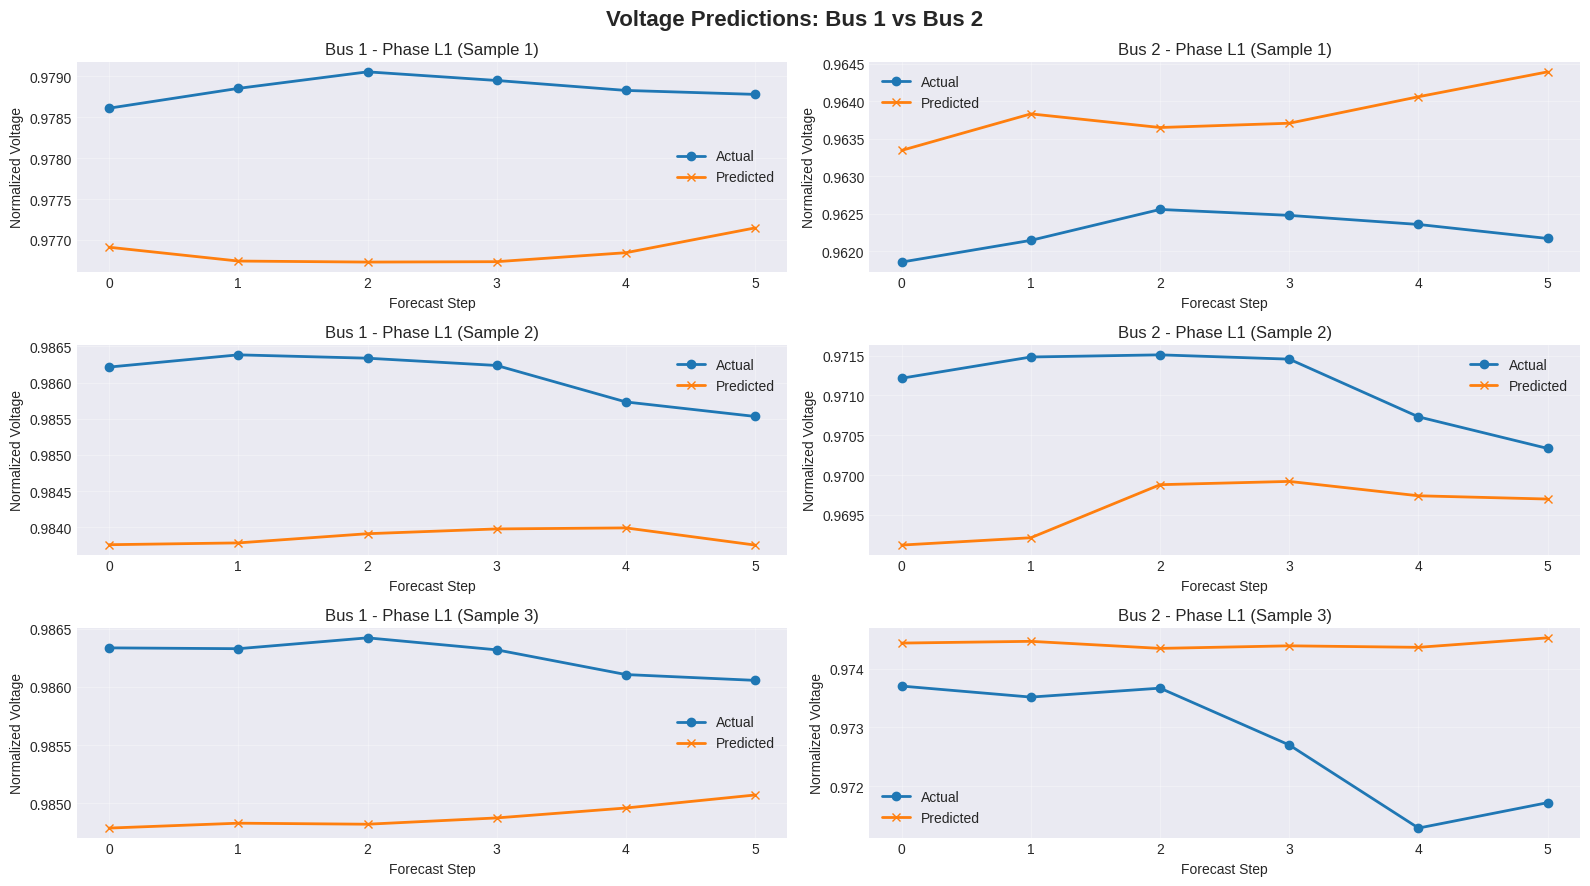

In [ ]:
# Prediction Visualisation
# Visualize predictions for both buses

n_samples = 3
indices = np.random.choice(len(X_test), n_samples, replace=False)

fig, axes = plt.subplots(n_samples, 2, figsize=(16, 3*n_samples))
fig.suptitle('Voltage Predictions: Bus 1 vs Bus 2', fontsize=16, fontweight='bold')

for i, idx in enumerate(indices):
    # Bus 1 - L1 voltage
    axes[i, 0].plot(y_test[idx, :, 0], 'o-', label='Actual', linewidth=2, markersize=6)
    axes[i, 0].plot(y_pred[idx, :, 0], 'x-', label='Predicted', linewidth=2, markersize=6)
    axes[i, 0].set_title(f'Bus 1 - Phase L1 (Sample {i+1})')
    axes[i, 0].set_xlabel('Forecast Step')
    axes[i, 0].set_ylabel('Normalized Voltage')
    axes[i, 0].legend()
    axes[i, 0].grid(True, alpha=0.3)

    # Bus 2 - L1 voltage
    axes[i, 1].plot(y_test[idx, :, 12], 'o-', label='Actual', linewidth=2, markersize=6)
    axes[i, 1].plot(y_pred[idx, :, 12], 'x-', label='Predicted', linewidth=2, markersize=6)
    axes[i, 1].set_title(f'Bus 2 - Phase L1 (Sample {i+1})')
    axes[i, 1].set_xlabel('Forecast Step')
    axes[i, 1].set_ylabel('Normalized Voltage')
    axes[i, 1].legend()
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Error Analysis

Prediction errors are analysed to identify systematic forecasting behaviour and evaluate the robustness of the proposed model across the test dataset.

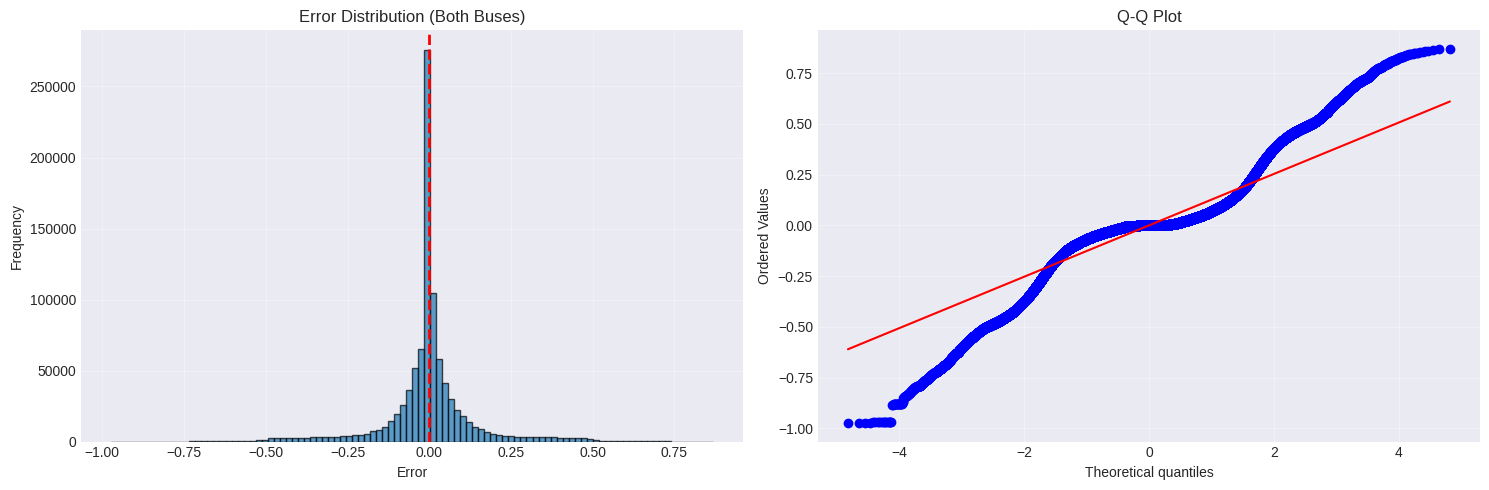

Error mean: -0.000430
Error std:  0.139010


In [ ]:
# Forecast Error Analysis

errors = y_test - y_pred
errors_flat = errors.flatten()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(errors_flat, bins=100, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Error Distribution (Both Buses)')
axes[0].set_xlabel('Error')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

stats.probplot(errors_flat, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Error mean: {errors_flat.mean():.6f}")
print(f"Error std:  {errors_flat.std():.6f}")

### Baseline Comparison Summary

The evaluation demonstrates the forecasting performance of the proposed CNN–Transformer model across multiple perspectives, including overall accuracy, per-bus performance, visual prediction quality, and forecast error analysis.

These results form the basis for the final exported evaluation outputs presented in the following section.

## Save Results

This section exports the key evaluation outputs generated throughout the analysis.

The exported files include overall model performance, per-bus evaluation metrics, voltage-only forecasting results, and other supporting outputs used to validate the proposed CNN–Transformer model.

In [ ]:
# Create Results Summary

results = {
    'Model': 'Multi-Node CNN-Transformer',
    'Nodes': 'Bus 1 + Bus 2',
    'Total Samples': len(X),
    'Train': len(X_train),
    'Val': len(X_val),
    'Test': len(X_test),
    'Features': X.shape[2],
    'Lookback': LOOKBACK,
    'Horizon': HORIZON,
    'Training Time (min)': round(training_time/60, 2),
    'Overall RMSE': round(rmse, 6),
    'Overall MAE': round(mae, 6),
    'Overall MAPE': round(mape, 2),
    'Overall R2': round(r2, 6),
    'Inference (ms/sample)': round(inference_time/len(X_test)*1000, 2)
}

# Save per-bus metrics
bus_metrics = {
    'Bus 1': bus1_metrics,
    'Bus 2': bus2_metrics
}

bus_df = pd.DataFrame(bus_metrics).T

print("\nMulti-Node Results:")
for k, v in results.items():
    print(f"  {k}: {v}")

print("\nFiles saved:")
print("  - best_multinode_model.keras")
print("  - multinode_results.csv")
print("  - multinode_comparison.csv")
print("  - per_bus_metrics.csv")


Multi-Node Results:
  Model: Multi-Node CNN-Transformer
  Nodes: Bus 1 + Bus 2
  Total Samples: 43927
  Train: 30748
  Val: 6589
  Test: 6590
  Features: 24
  Lookback: 60
  Horizon: 6
  Training Time (min): 11.33
  Overall RMSE: 0.13901
  Overall MAE: 0.077365
  Overall MAPE: 27785920.97
  Overall R2: 0.76199
  Inference (ms/sample): 0.5

Files saved:
  - best_multinode_model.keras
  - multinode_results.csv
  - multinode_comparison.csv
  - per_bus_metrics.csv


### Export Evaluation Results

The key evaluation outputs generated throughout this notebook are exported as CSV files.

These outputs summarise the overall model performance and the forecasting accuracy for each bus, providing reproducible results that support the accompanying dissertation and research paper.

In [ ]:
# Export Evaluation Results

# Create results directory if it does not exist
RESULTS_DIR.mkdir(exist_ok=True)

# Export overall model performance
pd.DataFrame([results]).to_csv(
    RESULTS_DIR / "multinode_results.csv",
    index=False,
)

# Export per-bus evaluation metrics
bus_df.to_csv(
    RESULTS_DIR / "per_bus_metrics.csv",
    index=True,
)

print("Evaluation results exported successfully.")
print(f"Location: {RESULTS_DIR}")



## Conclusion

This notebook presented the complete implementation of a CNN–Transformer hybrid model for forecasting voltage fluctuations in a multi-node smart grid.

The workflow included:

- Data loading and preprocessing
- Multi-node feature engineering
- Sequence generation
- CNN–Transformer model development
- Model training
- Performance evaluation
- Comparison with baseline approaches
- Export of evaluation results

### Key Findings

- The proposed CNN–Transformer architecture successfully captures both local and long-range temporal dependencies in voltage measurements.
- Multi-node learning enables the model to exploit spatial relationships between interconnected buses.
- Evaluation on unseen test data demonstrates the effectiveness of the proposed forecasting approach.
- The exported evaluation outputs support reproducibility and provide transparent reporting of model performance.

> **Dataset Availability**
>
> The original SoCal28Bus dataset is not included in this repository because it was obtained under restricted academic access. The generated evaluation outputs included in the `results/` directory provide transparency into the reported performance.